# **1. Data Overview**
#### This section loads, combines, and validates Premier League match data used for modelling.

In [2]:
# Importing libraries/packages
import pandas as pd
import numpy as np

print("Setup successful")

Setup successful


In [3]:
# Importing libraries/packages
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

print("Statsmodels, Matplotlib, and scikit-learn are working")

Statsmodels, Matplotlib, and scikit-learn are working


### __Concepts (Personal Notes):__
We are trying to model how many goals a Premier League team scores. 
Goals are countable events (count data) meaning they are non-negative and discrete integers. 
A Poisson regression is suitable to use here, which models the number of expected events (goals) in a fixed period, not a single outcome. 
The model estimates "lambda", a team's expected scoring rate, based on factors such as home/away advantage, a team's attacking ability, an opponent's defensive ability, etc. 
This allows us to calculate the probability of scoring different goal totals instead of predicting a single exact score.

In [4]:
# Importing 24-25 PL season data
df2425 = pd.read_csv("data/raw/PL24-25.csv")
df2425.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


In [5]:
#Visualising columns
df2425.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA',
       'AvgCAHH', 'AvgCAHA', 'BFECAHH', 'BFECAHA'],
      dtype='object', length=120)

In [6]:
# Check if the data is usable
df2425.info()
# The data is usable if the unit of observation is correct, key columns exist, data types make sense, 
# and there are no missing values in the target.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 120 entries, Div to BFECAHA
dtypes: float64(96), int64(16), object(8)
memory usage: 356.4+ KB


In [7]:
# Making new dataset with only the main columns, keeping only teams and goals
cols = ['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']
df2425_basic = df2425[cols]
df2425_basic.head()

,HomeTeam,AwayTeam,FTHG,FTAG
0,Man United,Fulham,1,0
1,Ipswich,Liverpool,0,2
2,Arsenal,Wolves,2,0
3,Everton,Brighton,0,3
4,Newcastle,Southampton,1,0


In [8]:
# Need to turn data from match-level to team-level
# Splitting each match row into two rows - one for home team, one for away team
# Home Team Data
home_df2425 = pd.DataFrame({
    'team': df2425_basic['HomeTeam'],
    'opponent': df2425_basic['AwayTeam'],
    'goals_scored': df2425_basic['FTHG'],
    'home': 1
})

# Away Team Data
away_df2425 = pd.DataFrame({
    'team': df2425_basic['AwayTeam'],
    'opponent': df2425_basic['HomeTeam'],
    'goals_scored': df2425_basic['FTAG'],
    'home': 0
})

In [9]:
home_df2425.head()

,team,opponent,goals_scored,home
0,Man United,Fulham,1,1
1,Ipswich,Liverpool,0,1
2,Arsenal,Wolves,2,1
3,Everton,Brighton,0,1
4,Newcastle,Southampton,1,1


In [10]:
away_df2425.head()

,team,opponent,goals_scored,home
0,Fulham,Man United,0,0
1,Liverpool,Ipswich,2,0
2,Wolves,Arsenal,0,0
3,Brighton,Everton,3,0
4,Southampton,Newcastle,0,0


In [11]:
# Stacks Home and Away datasets together, through "concat", with home stacked on top of away
# Now each match contributes two rows, forming 760 rows totals
# One row = one team in one mathc
team_df2425 = pd.concat([home_df2425, away_df2425], ignore_index=True)
    # "ignore_index" tells pandas to ignore index numbers, forgetting the old row numbers and creating new ones
    # without it, the combined data would have duplicate indexes, causing confusion
team_df2425.head()

,team,opponent,goals_scored,home
0,Man United,Fulham,1,1
1,Ipswich,Liverpool,0,1
2,Arsenal,Wolves,2,1
3,Everton,Brighton,0,1
4,Newcastle,Southampton,1,1


In [12]:
# Adds another column to indicate the season
team_df2425['season'] = '2024_2025'
team_df2425.head()

,team,opponent,goals_scored,home,season
0,Man United,Fulham,1,1,2024_2025
1,Ipswich,Liverpool,0,1,2024_2025
2,Arsenal,Wolves,2,1,2024_2025
3,Everton,Brighton,0,1,2024_2025
4,Newcastle,Southampton,1,1,2024_2025


In [13]:
# "Describe" gives summary statistics, such as mean, std.dev, etc, in order to check realism of the data
team_df2425.describe()
# we see the mean is 1.47, with a minimum of 0 and maximum of 7

,goals_scored,home
count,760.000000,760.000000
mean,1.467105,0.500000
std,1.234750,0.500329
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.500000
75%,2.000000,1.000000
max,7.000000,1.000000


# **2. Exploratory Analysis**
#### This section explores goal distributions and home advantage to motivate the modelling approach.

### **Graph - Goal distribution (count data motivation):** 
#### Goals scored in football matches are non-negative integers and typically exhibit a right-skewed distribution. This plot visualises the distribution of goals per team per match, motivating the use of a Poisson regression framework for modelling goal-scoring as count data.

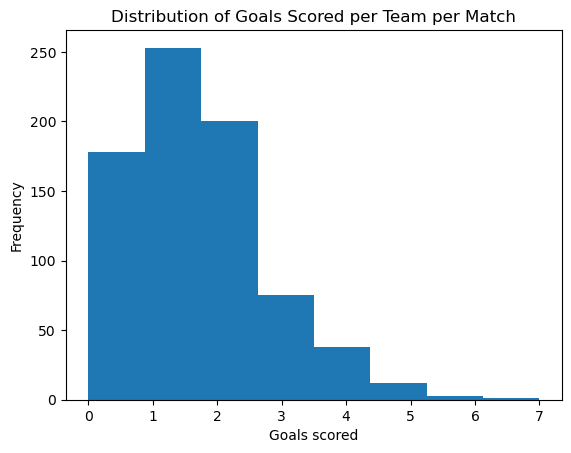

In [14]:
# Histogram showing goal distribution
import matplotlib.pyplot as plt

plt.hist(team_df2425['goals_scored'], bins=8)
    # "plt.hist" plots how often each goal count occurs
    # "bins" groups values into ranges, "=8" assigns 8 ranges
plt.xlabel('Goals scored')
plt.ylabel('Frequency')
plt.title('Distribution of Goals Scored per Team per Match')
plt.show()

In [15]:
# Home vs Away Scoring
avg_goals_home = team_df2425.groupby('home')['goals_scored'].mean()
    # "groupby('home') splits data into home (1) and away (0)
    # ".mean()" computes average goals for each group
# We see home teams score more on average than away teams - home advantage

### **Graph - Home vs away goal scoring:**
#### This plot compares average goals scored by teams when playing at home versus away. It provides an intuitive visual check for the presence of home advantage, which is later explicitly modelled in the Poisson regression.

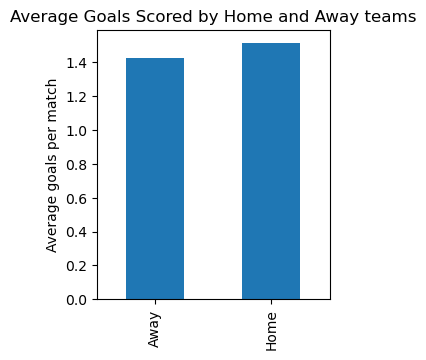

In [16]:
# Plot home advantage effect
avg_goals_home_name = avg_goals_home.rename(index={0: 'Away', 1:'Home'})

plt.figure(figsize=(3,3.5)) # makes the plot readable
avg_goals_home_name.plot(kind='bar') # indicates a bar chart
plt.xlabel('')
plt.ylabel('Average goals per match')
plt.title('Average Goals Scored by Home and Away teams')
plt.show()

In [17]:
# Team-level scoring averages
avg_goals_team = team_df2425.groupby('team')['goals_scored'].mean().sort_values(ascending=False)
    # splits data into groups by each team
    # "sort_values" sorts teams by average goals
avg_goals_team.head()
# We see stronger teams score more goals on average - performance differences

team
Liverpool    2.263158
Man City     1.894737
Arsenal      1.815789
Newcastle    1.789474
Brentford    1.736842
Name: goals_scored, dtype: float64

### **Graph - Team goal scoring:**
#### This plot compares average goals scored by differen teams. It provides an intuitive visual check for the presence of attack strength, which is later explicitly modelled in the Poisson regression.

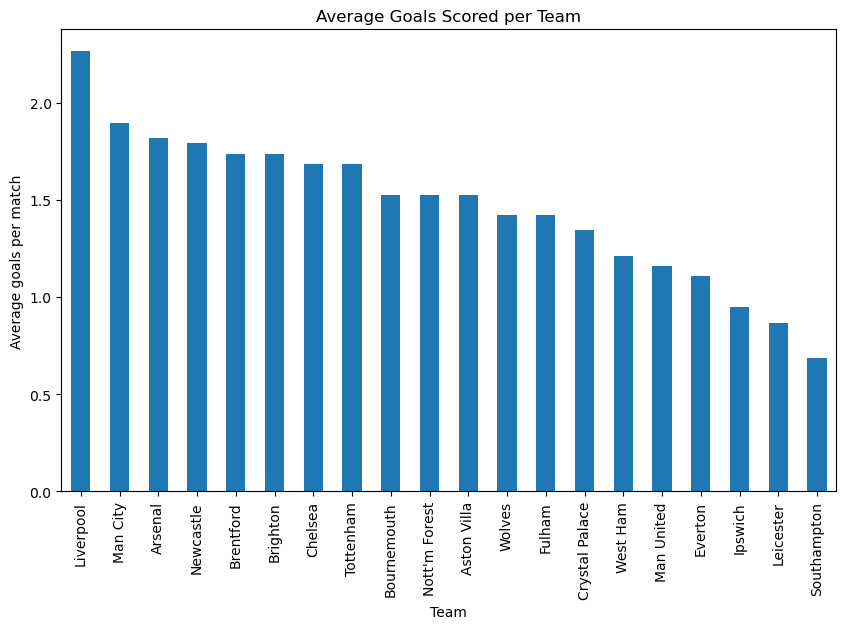

In [18]:
# Plot average goals per team
plt.figure(figsize=(10,6)) # makes the plot readable
avg_goals_team.plot(kind='bar') # indicates a bar chart
plt.xlabel('Team')
plt.ylabel('Average goals per match')
plt.title('Average Goals Scored per Team')
plt.show()

### __Variation (Personal Notes):__
Goal distribution shows that most teams score 0-2 goals, concentrated around low values, with a right-skewed distribution, as higher goal counts are seen less often.
Home advantage clearly exists as home teams average more goals (1.51) than away teams (1.42). Teams also have performance differences, with stronger attacks scoring more on average, such as Liverpool (2.26) scoring more often than Brentford (1.74).

In [19]:
# Baseline 1: Calculating average number of goals per team per match
league_avg_goals = team_df2425['goals_scored'].mean()
league_avg_goals

# This gives us the weakest reasonable prediction on the amount of goals a team will score

np.float64(1.4671052631578947)

In [20]:
# Baseline 2: Home vs Away average goals
home_away_avg = team_df2425.groupby('home')['goals_scored'].mean()
home_away_avg

# This is an upgraded prediction, predicting different goal rates depending if a team is home or away

home
0    1.421053
1    1.513158
Name: goals_scored, dtype: float64

In [21]:
# Naive goal prediction rule - Forming Baseline Pred column based on Home/Away
team_df2425['baseline_pred'] = team_df2425['home'].map(lambda x: home_away_avg[x]) # lambda is just a tiny, unnamed function
    # ".map" goes through values in 'home' (0 or 1) and maps it to a value in 'home_away_avg'
    # 0 is mapped to the away avg and 1 is mapped to the home avg, forming our 'baseline_pred' column
team_df2425[['goals_scored', 'baseline_pred']].head()

# We start with a very basic prediction rule
# 1) Predict avg home goals for home teams 2) Predict avg away goals for away teams
# This is deliberately a weak baseline, using minimal information (only home/away advantage)
# There is no "correct" baseline, but we have purposely used a weaker one to show improvements later

,goals_scored,baseline_pred
0,1,1.513158
1,0,1.513158
2,2,1.513158
3,0,1.513158
4,1,1.513158


In [22]:
# How good is the Baseline? - simple error measure
# Model Absolute Error(MAE)
mae_baseline = abs(team_df2425['goals_scored'] - team_df2425['baseline_pred']).mean() # abs ensures pos/neg errors do not cancel out
mae_baseline

# This tells us on average how far off the baseline prediction is 

np.float64(0.9971260387811633)

### __Baselines (Personal Notes):__
A simple baseline prediction rule using league and home-away averages provides a basic benchmark to beat. However, to justify a more complex model, it must do better than this with a lower error.

# **3. Poisson Goal Model**
#### This section models goals as count data using a Poisson GLM with attack, defence, and home effects.

In [23]:
# Preparing data for modelling
y = team_df2425['goals_scored']
X = team_df2425[['home']]
X = sm.add_constant(X) # adds an intercept term for the baseline scoring rate

In [24]:
# Fit the Poisson model
poisson_home_model = sm.GLM(y, X, family=sm.families.Poisson())
    # GLM is generalised linear model
    # "families.Poisson" specifies we are modelling count data
poisson_home_results = poisson_home_model.fit() # ".fit()" estimates parameters from the data
poisson_home_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           goals_scored   No. Observations:                  760
Model:                            GLM   Df Residuals:                      758
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1166.6
Date:                Wed, 07 Jan 2026   Deviance:                       899.37
Time:                        19:02:18   Pearson chi2:                     787.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001445
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3514      0.043      8.166      0.000       0.267       0.436
home           0.0628      0.060      1.048      0.295      -0.055       0.180
==============================================================================
"""

In [44]:
# Interpreting Coefficients:
# These are on the log scale, so to interpret them we need to exponentiate 
np.exp(poisson_home_results.params)
    # This gives exp(const), the baseline for away teams, and gives exp(home), the multiplicative home advantage

const    1.421053
home     1.064815
dtype: float64

### __GLM and Poisson Theory (Personal Notes):__
__GLMs__ are linear in the parameters, but use a non-linear link function (e.g. log, logit) to connect predictors to the outcome’s mean in a way that respects the data’s constraints. In contrast, standard linear regression is linear in parameters, linking predictors to the outcome directly without a non-linear link function.
<br>__Poisson regression__ uses a log link so linear predictors map to positive, multiplicative scoring rates. The equation is like: log(λ) = β0 + β1*x1 + ..., turning into: λ = exp(β0 + β1*x1 + ...). Coefficients are log-rate changes, but importantly, exponentiated coefficients are rate ratios 
<br> This __Poisson GLM model__ is a statistically estimated version of the home and away basline which just reported averages. Instead of using rules of thumb, it estimates scoring rates statistically using econometrics.

#### **Next Step: Including team attack and defence effects**
Regression becomes log(λ) = β0 + β1*home + α(team) + δ(opponent), where α is attack effect and δ is defence effect

In [27]:
# Encoding all teams as categorical variables
team_df2425['team'] = team_df2425['team'].astype('category')
team_df2425['opponent'] = team_df2425['opponent'].astype('category')
# This tells python that these are categorial variables, not numbers, allowing statsmodels to create dummy variables.

In [ ]:
# Specify the Poisson model with team effects
import statsmodels.formula.api as smf
poisson_team_home_model = smf.glm(
            formula='goals_scored ~ home + team + opponent', 
            data=team_df2425, 
            family=sm.families.Poisson()
        )
    # "formula=" describes the model in symbolic form, and "team+opponent" adds a dummy variable for each team and opponent
    # Statsmodels (not Python) interprets the formula as “y is modelled as a function of the x variables” and converts it into
    # a numerical design matrix for estimation.
    # One team (Arsenal) is treated as the baseline/intercept as a reference category, with attack/defence effects being relative to them.
poisson_team_results = poisson_team_home_model.fit()
poisson_team_results.summary()

# You can sketch the logic by hand, but Poisson regression estimates the effects optimally and consistently across all matches, by
# solving an optimisation problem (MLE) using all the data at once.

In [ ]:
# To interpret the results, we convert the coefficients to rate ratios
rate_ratios = np.exp(poisson_team_results.params) # can add ".sort_values(ascending=False)"
rate_ratios
# The results now show rate ratios:
# For attack effects, a value > 1 increases expected goals, but values < 1 decreases expected goals (i.e. weaker attack)
# For defence effects, a value > 1 increases expected goals, but values < 1 decreases expected goals (i.e. playing a stronger defence)

# **4. Evaluation**
#### This section evaluates predictive performance and model fit using error metrics and diagnostics to see if complexity actually improved our predictions.

In [30]:
# Generating Predictions
team_df2425['poisson_pred'] = poisson_team_results.predict(team_df2425) 
    # creates column of predictions of expected goals for each observation in team_df2425 using all model components (home, team, opponent)
team_df2425[['goals_scored', 'poisson_pred']].head()

,goals_scored,poisson_pred
0,1,1.154927
1,0,0.758553
2,2,2.275079
3,0,1.207324
4,1,2.756102


In [31]:
# Compute prediction error (MAE)
mae_poisson = abs(team_df2425['goals_scored'] - team_df2425['poisson_pred']).mean()
print(mae_poisson)
# This is the average prediction error in goals, and we see that PoissonMAE < BaselineMAE, showing improved prediction accuracy.

print("Poisson MAE: " + str(mae_poisson) + " vs Baseline MAE: " + str(mae_baseline))
# Adding team attack and defence effects reduces average prediction error by 0.116 goals.

0.8813206179600462
Poisson MAE: 0.8813206179600462 vs Baseline MAE: 0.9971260387811633


### **Graph - Predicted vs actual goals:**
#### This plot compares the Poisson model’s predicted expected goals to actual goals scored. It serves as a visual diagnostic of model fit, indicating how closely the model tracks observed outcomes across matches.

<function matplotlib.pyplot.show(close=None, block=None)>

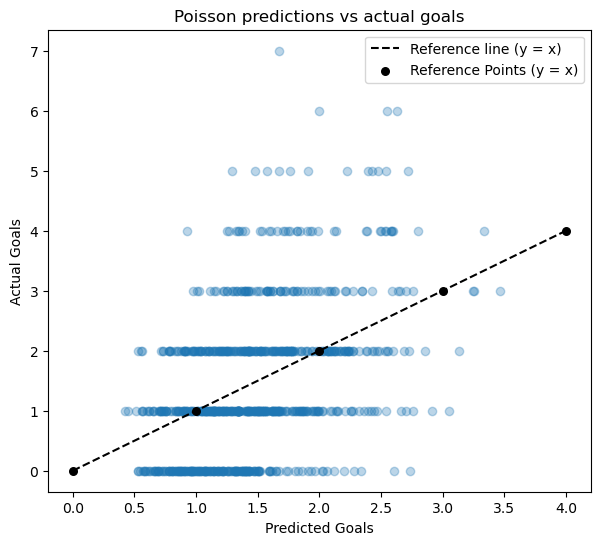

In [45]:
# Intuition Check with a Scatter Plot
x=team_df2425['poisson_pred']
y=team_df2425['goals_scored']

plt.figure(figsize=(7,6))
plt.scatter(x, y, alpha=0.3)
plt.xlabel('Predicted Goals')
plt.ylabel('Actual Goals')
plt.title('Poisson predictions vs actual goals')

# Diagonal y=x line over the visible range
plt.plot([0, 4], [0, 4], c='black', linestyle='--', label='Reference line (y = x)')

# Extra reference points
ref = np.array([0,1,2,3,4])
plt.scatter(ref, ref, c='black', s=30, label='Reference Points (y = x)')

plt.legend()
plt.show

In [33]:
# LOG-LIKELIHOOD
print("Log Likelihood with just home variables: " + str(poisson_home_results.llf))
print("Log Likelihood with home and team variables: " + str(poisson_team_results.llf))

Log Likelihood with just home variables: -1166.571095731107
Log Likelihood with home and team variables: -1096.3661808166066


### __Mean Absolute Error (MAE) vs Log-likelihood (Personal Notes):__
**MAE** measures prediction accuracy in goals, measuring the closeness of predictions. **Log-likelihood** measures how probable (plausible) the observed goal counts are under the Poisson (distribution/DGP) assumption, evaluating how well the Poisson model explains the observed goals, not how close predictions are numerically. Log-likelihood punishes overconfidence.
<br>__e.g.__ if a model consistently underestimates by 0.2 goals, MAE looks good and small, but log-likelihood looks consistently worse as the model assigns systematically incorrect probabilities.
Models with team attack and defence effects achieved higher log-likelihood than simpler baselines, such as those with only home advantage.

### __Poisson Evaluation:__
__Benefits:__
<br>The Poisson model incorporating team attack, opponent defence, and home advantage improves predictive accuracy relative to a naive baseline. While results are in-sample, the reduction in MAE and log-likelihood suggests meaningful structure in the data.
<br>__Limitations:__
<br>There is no train-test split yet so the data is tested in-sample, meaning coefficients may overfit. Future work could regularise (shrinkage) or validate out-of-sample.

# **5. Logistic Benchmark**
#### So far we have modelled goals (counts), but now we shift to modelling match outcomes (win/draw/loss). We use the same information from the Poisson model to train a simple Logistic regression.


In [34]:
# Create match-level outcomes
matches_df = df2425_basic.copy()
    # creates a new, independent DataFrame that is safe to modify without affecting df2425_basic
    # this is used specifically for classification labels, separate to raw match data
matches_df['result'] = np.where(matches_df['FTHG'] > matches_df['FTAG'], 'H', 
                                np.where(matches_df['FTAG'] > matches_df['FTHG'], 'A', 'D')
                               )
    # "np.where()" is a conditional assignment and works on entire columns at once so is faster than if/else
    # it works the same way, if home>away assign 'H', else if away>home assign 'A', else assign 'D'
matches_df[['HomeTeam', 'AwayTeam', 'result']].head() 
    # double [[]] is used to select multiple columns rather than one, and returns a DataFrame

,HomeTeam,AwayTeam,result
0,Man United,Fulham,H
1,Ipswich,Liverpool,A
2,Arsenal,Wolves,H
3,Everton,Brighton,A
4,Newcastle,Southampton,H


In [35]:
# Encode outcome as numbers - logistic regression needs numerical labels
# We start with binary classification - home win (H) or not home win (not H)
matches_df['home_win'] = (matches_df['result'] == 'H').astype(int)
    # does a boolean comparision and whether it is true/false it converts it to an integer of 1/0
    # it then stores it as a new column, framing it as a binary classification
matches_df['home_win'].value_counts()
    # counts how many of each value (0 and 1) there are in this new column

# Win–draw–loss classification is feasible but adds complexity without improving the core comparison, 
# so binary classification (home W vs not home W) is an appropriate first ML benchmark.

home_win
0    225
1    155
Name: count, dtype: int64

In [36]:
# We use the same features and logic as Poisson, with team strength and home advantage
# But for ML, we need numeric feaures, so we build a simple feature matrix
matches_df['home_xg'] = poisson_team_results.predict(
                                        team_df2425[team_df2425['home']==1]).values
    # "team_df2425['home']==1" filters the team-level dataset to keep only rows where the team was playing at home
    # this subset still has team strength and home advantage
    # ".predict()" uses the poisson model to predict the no. of goals using the same variables as before
    # ".values" converts a panda object (series/DF), which aligns data by index, into a NumPy array, which aligns data purely by position
    # Index: row label/identifier (e.g. 25th May), it is equal to position by default unless explicitly changed
    # Position: row index/order (e.g. 3rd row --> 2)
matches_df['away_xg'] = poisson_team_results.predict(
                                        team_df2425[team_df2425['home']==0]).values

matches_df['xg_diff'] = matches_df['home_xg'] - matches_df['away_xg']
    # calculates the expected goal difference, showing if home or away team is stronger
    # this is the quantity that a classifier cares about

# Key Assumption:
# Code assumes that team_df2425[home==1] and [home==0] are in the same order as matches_df
# This is true as the team-level data was created by stacking home rows first and then away rows
# If the order were off, we would mis-match home and away xG (i.e. matching teams from different matches)

In [37]:
# Train logistic regession
from sklearn.linear_model import LogisticRegression

X = matches_df[['xg_diff']] # defines the feature matrix, using xG diff as the predictor
y = matches_df['home_win'] # defines the target variable (1 home win / 0 not home win)

logit_model = LogisticRegression() # creates an empty logistic regression model
logit_model.fit(X,y) # fits this model by finding best coefficients to map X to y
    # note that logistiic regression includes an intercept by default

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
# Interpret coefficients
logit_model.coef_, logit_model.intercept_

(array([[1.14968459]]), array([-0.56725173]))

### __Coefficients Meaning (Personal Notes):__
__Formula: logit(Prb of home win) = β0 + β1*xG_diff__
<br> - positive β1 means a higher xG difference increases home win probability
<br>__Breaking down the exact figures:__
<br>Intercept = -0.57, this is the log-odds of a home win when xG_diff = 0
<br> - converting this to a probability gives 0.36, 36% of a home win
<br>Coefficient = 1.15, means a 1 unit increase in xG_diff increases log-odds of home win by 1.15 (formula above)
<br>   - this means that the odds of a home win increase by about 3.2 (comparative statement, not a probability)
<br>__Odds__: measures how likely an event happening is relative to it not happening (can be > 1, though probabilities cant)
<br> - Odds = P(event) / 1 - P(event), a ratio comparing an event happening to not happening
<br> - Odds tells you how much stronger, not the chance
<br> - To convert to actual probabilities, we use the logistic formula (1+e^-t)^-1

### __Comparing poisson and logistic models:__
We need to compare them along two dimensions, articulating the trade-offs
<br>__Accuracy__ - depends on MAE/log-likelihood for Poisson and classification accuracy for Logistic
<br> - Not ranking globally but are comparing approaches
<br>__Interpretability__ - can I explain why the model predicts this and do coefficients link to football logic
<br> - Econometric models are designed for this but ML models often trade this off

In [39]:
# Evaluating logistic regression accuracy
from sklearn.metrics import accuracy_score

y_pred = logit_model.predict(X)
accuracy = accuracy_score(y, y_pred)
accuracy
# This shows the proportion of matches correctly classified, 67.4%
# Note that always predicting "not home win" is correct 55-60% of the time, so accuracy must be interpreted carefully

0.6736842105263158

In [40]:
# Evaluating poisson regression
# We already have the MAE and log-likelihood for Poisson team model
print("MAE: " + str(mae_poisson) + " and Log Likelihood: " + str(poisson_team_results.llf))

# Poisson model captures team strength sensibily and improves on the baseline model.
# Also, the coefficients are interpretable, showing the strength of attack/defence/home advantage.

MAE: 0.8813206179600462 and Log Likelihood: -1096.3661808166066


# 6. Summary and Comparison 
#### This section compares statistical and machine learning approaches, highlighting key trade-offs.

### __Comparison Framework between Poisson (Statistical) and Logistic (ML-style) (Personal Notes):__
<br>__Statistical modelling__ focuses on understanding mechanisms and interpreting parameters (answering the "why").
<br> - For poisson, predictions are still produced but are a by-product of the structural explanation of the goal-scoring process.
<br>__Machine Learning__ focuses on prediction accuracy with less emphasiss on parameter interpretation.
<br> - Here, prediction is the primary objective, not a consequence of explaining the DGP.

<br>__ACCURACY:__
<br>__Logistic__: directly optimised for win prediction, evaluated using simple accuracy metrics.
<br>__Poisson__: optimised for prediction goals not match outcomes, so outcome accuracy emerges indirectly
Logistic usually wins on raw outcome accuracy

<br>__INTERPRETABILITY:__
<br>__Logistic__: relies on one coefficient to summarise everything (xG_diff), so less structural insight
<br>__Poisson__: separare attack, defence, home advantage effects, so coefficients map directly to football concepts
<br> - Poisson wins on interpretability

<br>__SUMMARY:__
<br>__The Poisson model__ prioritises interpretability by explicitly modelling goal-scoring as a function of team attack strength, opponent defence strength, and home advantage. This structure allows direct football insights but is not optimised for predicting match outcomes.
<br>In contrast, __the logistic regression__ reframes the problem as a classification task and achieves reasonable predictive accuracy using a compact feature representation. However, this comes at the cost of reduced interpretability, as the model does not explicitly estimate parameters corresponding to underlying football mechanisms.
<br>__e.g.__ if manager asks "why are we predicted to lose?"
<br> Logistic: "xG difference is -0.6"
<br> Poisson: "our attack is 20% weaker and their defence is 30% stronger"
<br> - Logistic relies on a single summary feature, while Poisson models scoring mechanisms.

In [41]:
summary_table = pd.DataFrame([
    {
        "Model": "Poisson regression (GLM)",
        "Target": "Goals scored",
        "Key features": "Home + team attack + opponent defence",
        "Strength": "Interpretable mechanism-level effects",
        "Limitation": "Not optimised for match outcome classification"
    },
    {
        "Model": "Logistic regression ( classifier)",
        "Target": "Home win vs not home win",
        "Key features": "xG difference (from Poisson predictions)",
        "Strength": "Directly optimised for outcome prediction",
        "Limitation": "Reduced structural interpretability (compressed feature)"
    }
])

summary_table
# summary_table.to_markdown(index=False)

,Model,Target,Key features,Strength,Limitation
0,Poisson regression (GLM),Goals scored,Home + team attack + opponent defence,Interpretable mechanism-level effects,Not optimised for match outcome classification
1,Logistic regression ( classifier),Home win vs not home win,xG difference (from Poisson predictions),Directly optimised for outcome prediction,Reduced structural interpretability (compresse...


### Key visuals summary

- **[Goal distribution]**
  <br>Demonstrates that goals are discrete, skewed count data, justifying the use of a Poisson model.

- **[Home vs away goal scoring]**  
  Confirms the presence of home advantage through higher average goals for home teams.

- **[Predicted vs actual goals]**  
  Provides a visual check of model fit, showing how predicted goals align with observed outcomes.